# Candidate Sets v1 — Species Distribution Analysis

Distribution of species counts across all testcases in `candidate_sets_v1.tsv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df = pd.read_csv('candidate_sets_v1.tsv', sep='\t')
print(f'{len(df)} testcases loaded')
df.head(3)

173 testcases loaded


,Gene,Birch #,Qn,N insertions,Species
0,ZFP28,2,57.77,12,"Phyllostomus_discolor, Artibeus_jamaicensis, C..."
1,OR1Q1,1,39.99,13,"Addax_nasomaculatus, Kobus_leche_leche, Procap..."
2,STK19,1,35.55,16,"Diceros_bicornis_minor, Paramormyrops_kingsley..."


In [2]:
# Count unique species per testcase (deduplicated)
df['n_species_raw'] = df['N insertions']  # as reported in file
df['n_species_unique'] = df['Species'].apply(
    lambda s: len(set(x.strip() for x in s.split(',') if x.strip()))
)

# How many testcases have duplicates?
n_with_dupes = (df['n_species_raw'] != df['n_species_unique']).sum()
print(f'Testcases with duplicate species entries: {n_with_dupes}')
print(f'N insertions range:   {df["n_species_raw"].min()} – {df["n_species_raw"].max()}')
print(f'Unique species range: {df["n_species_unique"].min()} – {df["n_species_unique"].max()}')
df[df['n_species_raw'] != df['n_species_unique']][['Gene', 'n_species_raw', 'n_species_unique']].head(10)

Testcases with duplicate species entries: 24
N insertions range:   5 – 105
Unique species range: 4 – 104


,Gene,n_species_raw,n_species_unique
1,OR1Q1,13,12
3,H4C7,26,18
31,NELFA,5,4
34,KRBA2,10,6
38,CSN2,18,17
39,COPS2,18,17
46,SMU1,25,24
63,ARIH1,32,27
75,ASB6,51,50
77,ARIH1,65,58


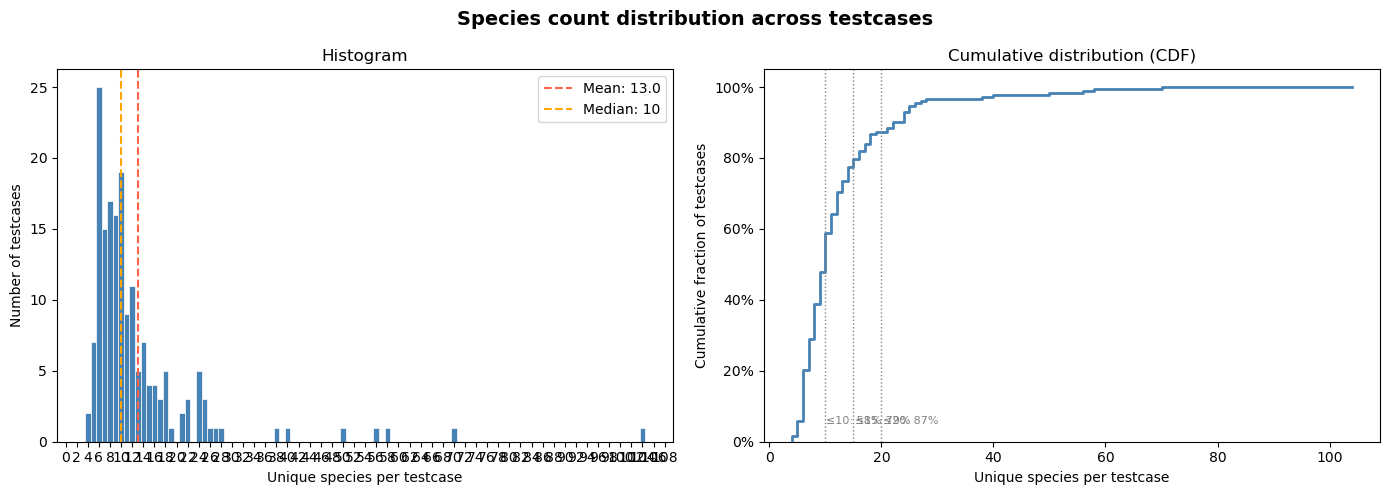

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Species count distribution across testcases', fontsize=14, fontweight='bold')

col = 'n_species_unique'
counts = df[col]

bins = range(counts.min(), counts.max() + 2)

# --- Histogram ---
ax = axes[0]
ax.hist(counts, bins=bins, color='steelblue', edgecolor='white', linewidth=0.5, align='left')
ax.axvline(counts.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'Mean: {counts.mean():.1f}')
ax.axvline(counts.median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {counts.median():.0f}')
ax.set_xlabel('Unique species per testcase')
ax.set_ylabel('Number of testcases')
ax.set_title('Histogram')
ax.legend()
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))

# --- CDF ---
ax2 = axes[1]
sorted_counts = np.sort(counts)
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
ax2.step(sorted_counts, cdf, color='steelblue', linewidth=2)
for threshold in [10, 15, 20]:
    pct = (counts <= threshold).mean() * 100
    ax2.axvline(threshold, color='gray', linestyle=':', linewidth=1)
    ax2.text(threshold + 0.2, 0.05, f'≤{threshold}: {pct:.0f}%', fontsize=8, color='gray')
ax2.set_xlabel('Unique species per testcase')
ax2.set_ylabel('Cumulative fraction of testcases')
ax2.set_title('Cumulative distribution (CDF)')
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('species_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Summary statistics
summary = counts.describe().rename('unique species')
summary['# testcases with > 15 species'] = (counts > 15).sum()
summary['# testcases with > 20 species'] = (counts > 20).sum()
summary['# testcases with > 23 species'] = (counts > 23).sum()
print(summary.to_string())

count                            173.000000
mean                              12.982659
std                               11.730240
min                                4.000000
25%                                7.000000
50%                               10.000000
75%                               14.000000
max                              104.000000
# testcases with > 15 species     36.000000
# testcases with > 20 species     23.000000
# testcases with > 23 species     18.000000


In [5]:
# Bin by problem size bracket
brackets = [
    ('Small  (≤ 8)',    counts <= 8),
    ('Medium (9–15)',   (counts > 8)  & (counts <= 15)),
    ('Large  (16–22)', (counts > 15) & (counts <= 22)),
    ('XL     (≥ 23)',   counts >= 23),
]

print(f'{'Bracket':<20} {'Count':>8} {'Pct':>8}')
print('-' * 38)
for label, mask in brackets:
    n = mask.sum()
    print(f'{label:<20} {n:>8} {n/len(df)*100:>7.1f}%')
print(f'{'Total':<20} {len(df):>8}')

Bracket                 Count      Pct
--------------------------------------
Small  (≤ 8)               66    38.2%
Medium (9–15)              71    41.0%
Large  (16–22)             18    10.4%
XL     (≥ 23)              18    10.4%
Total                     173
